# Conformal Prediction & Calibration : Random Split

Rows are split into train/val/test at random, so a single publication can appear across multiple splits. Fits KNN, SVR, and NuSVR, then evaluates conformal prediction intervals and per-publication coverage/calibration. Compare against `01_group_split.ipynb`, which holds entire publications out of train instead.

In [29]:
import sys
sys.path.insert(0, '../Week-5-6-7-8')

import json
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR, NuSVR

from helpers.modeling import prepare_data, identify_column_types, create_preprocessor
from uncertainty import run_conformal, calibration_table,plot_interval_band

with open('../Week-5-6-7-8/results.json', 'r') as f:
    results = json.load(f)

df = pd.read_csv("../Datasets/processed/UHPC_dataset/semantic_recoding_features_50_with_publications.csv")

In [30]:
df_shared_pub = df.drop(columns='paper_reference')
target_col = 'cs_28d'

X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(df_shared_pub, target_col)

pub_test = df.loc[X_test.index, 'paper_reference']  
pub_val  = df.loc[X_val.index,  'paper_reference']  

print(f"Train set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

X = df_shared_pub.drop(columns=[target_col])
numerical_cols, one_hot_columns, k_fold_columns = identify_column_types(X)

preprocessor = create_preprocessor(numerical_cols, one_hot_columns, k_fold_columns,
                                   handle_unknown='ignore')

print(f"After encoding Training Set Shape: {preprocessor.fit_transform(X_train, y_train).shape}")
print(f"After encoding Validation Set Shape: {preprocessor.transform(X_val).shape}")
print(f"After encoding Test Set Shape: {preprocessor.transform(X_test).shape}")



Train set size: 1451
Validation set size: 311
Test set size: 311
After encoding Training Set Shape: (1451, 60)
After encoding Validation Set Shape: (311, 60)
After encoding Test Set Shape: (311, 60)


In [21]:
processed = preprocessor.transform(X_train)
df1 = pd.DataFrame(processed)
df1.head()

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
0,-0.749379,0.065435,-0.973941,-0.823883,0.451098,-1.435367,-0.420784,-0.231084,-0.526882,-0.2788,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-0.545141,0.065435,-0.679384,0.711503,0.574214,-0.003464,-0.420784,-0.231084,-0.526882,-0.2788,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-0.749379,0.742881,0.029365,-0.823883,0.687421,0.089832,0.209871,-0.231084,-0.526882,-0.2788,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,-0.545141,0.065435,1.072499,0.711503,-1.878287,-0.826023,1.287198,-0.231084,-0.526882,-0.2788,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,1.101296,0.065435,0.943303,0.711503,0.476114,0.472755,-0.420784,-0.231084,-0.526882,-0.2788,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [22]:
pipeline_knn, train_knn, test_knn, q_knn, intervals_knn, calibration_knn = run_conformal(
    KNeighborsRegressor, 'knn', results, 'recoded_50', preprocessor,
    X_train, y_train, X_val, y_val, X_test, y_test, pub_test
)
print(f"Train: {train_knn}")
print(f"Test:  {test_knn}")
print(f"Conformal q (90%): {q_knn:.2f}")
calibration_knn

Train: {'RMSE': np.float64(5.205589250920187), 'MAE': 3.085537085029864, 'R2': 0.9796630677440915, 'Correlation': np.float64(0.9898965615827696), 'Mean_Residual': np.float64(-0.12393217502612994), 'N': 1451}
Test:  {'RMSE': np.float64(15.195877614901061), 'MAE': 10.682093998521166, 'R2': 0.8025688444052277, 'Correlation': np.float64(0.8965582251087545), 'Mean_Residual': np.float64(1.0282742395607152), 'N': 311}
Conformal q (90%): 28.13


,publication,n_rows,mean_true,mean_prediction,coverage,interval_width,mean_residual,mean_distance
0,Ref-1-data,2,119.250,126.755618,1.0,56.269971,7.505618,2.483831
1,Ref-10-Research,4,152.125,132.665467,0.5,56.269971,23.853606,4.246048
2,Ref-100-Research,1,105.600,110.644017,1.0,56.269971,5.044017,2.902133
3,Ref-101-Research,2,140.550,151.625549,1.0,56.269971,11.075549,1.337418
4,Ref-102-Research,2,158.000,158.869087,1.0,56.269971,1.780639,3.032631
...,...,...,...,...,...,...,...,...
100,Ref-92-Research,1,149.000,177.198377,0.0,56.269971,28.198377,2.290270
101,Ref-93-Research,1,156.000,138.534600,1.0,56.269971,17.465400,2.823983
102,Ref-94-Research,1,176.000,169.913957,1.0,56.269971,6.086043,5.071201
103,Ref-96-Research,1,126.000,135.819157,1.0,56.269971,9.819157,4.592409


In [23]:
pipeline_svr, train_svr, test_svr, q_svr, intervals_svr, calibration_svr = run_conformal(
    SVR, 'svr', results, 'recoded_50', preprocessor,
    X_train, y_train, X_val, y_val, X_test, y_test, pub_test
)
print(f"Train: {train_svr}")
print(f"Test:  {test_svr}")
print(f"Conformal q (90%): {q_svr:.2f}")
calibration_svr

Train: {'RMSE': np.float64(8.508326079519819), 'MAE': 5.341023331713636, 'R2': 0.945670726248731, 'Correlation': np.float64(0.9726849716730638), 'Mean_Residual': np.float64(0.08860678284603098), 'N': 1451}
Test:  {'RMSE': np.float64(13.335781686311135), 'MAE': 9.360455999540019, 'R2': 0.8479448732038605, 'Correlation': np.float64(0.9211870563995028), 'Mean_Residual': np.float64(0.6899026063935033), 'N': 311}
Conformal q (90%): 25.92


,publication,n_rows,mean_true,mean_prediction,coverage,interval_width,mean_residual,mean_distance
0,Ref-1-data,2,119.250,124.139578,1.0,51.83563,4.889578,1.772302
1,Ref-10-Research,4,152.125,142.040750,1.0,51.83563,10.084250,2.448926
2,Ref-100-Research,1,105.600,123.538103,1.0,51.83563,17.938103,2.018654
3,Ref-101-Research,2,140.550,144.907988,1.0,51.83563,4.357988,0.676201
4,Ref-102-Research,2,158.000,160.884883,1.0,51.83563,6.964386,1.830935
...,...,...,...,...,...,...,...,...
100,Ref-92-Research,1,149.000,143.047902,1.0,51.83563,5.952098,1.865692
101,Ref-93-Research,1,156.000,133.621108,1.0,51.83563,22.378892,1.949492
102,Ref-94-Research,1,176.000,173.441269,1.0,51.83563,2.558731,2.575213
103,Ref-96-Research,1,126.000,136.386514,1.0,51.83563,10.386514,2.791914


In [24]:
pipeline_nusvr, train_nusvr, test_nusvr, q_nusvr, intervals_nusvr, calibration_nusvr = run_conformal(
    NuSVR, 'nusvr', results, 'recoded_50', preprocessor,
    X_train, y_train, X_val, y_val, X_test, y_test, pub_test
)
print(f"Train: {train_nusvr}")
print(f"Test:  {test_nusvr}")
print(f"Conformal q (90%): {q_nusvr:.2f}")
calibration_nusvr

Train: {'RMSE': np.float64(8.556962302482678), 'MAE': 5.218884833524723, 'R2': 0.9450478251161817, 'Correlation': np.float64(0.9722202977588462), 'Mean_Residual': np.float64(-0.017386717347077297), 'N': 1451}
Test:  {'RMSE': np.float64(13.35512685193459), 'MAE': 9.38768320343447, 'R2': 0.8475034044988613, 'Correlation': np.float64(0.9210477280701324), 'Mean_Residual': np.float64(0.5081667144518182), 'N': 311}
Conformal q (90%): 24.78


,publication,n_rows,mean_true,mean_prediction,coverage,interval_width,mean_residual,mean_distance
0,Ref-1-data,2,119.250,122.992308,1.0,49.566572,3.742308,1.773215
1,Ref-10-Research,4,152.125,141.536999,1.0,49.566572,10.588001,2.449078
2,Ref-100-Research,1,105.600,121.079974,1.0,49.566572,15.479974,2.015978
3,Ref-101-Research,2,140.550,145.432031,1.0,49.566572,4.882031,0.676201
4,Ref-102-Research,2,158.000,161.981894,1.0,49.566572,5.325481,1.830975
...,...,...,...,...,...,...,...,...
100,Ref-92-Research,1,149.000,148.808671,1.0,49.566572,0.191329,1.863692
101,Ref-93-Research,1,156.000,138.912825,1.0,49.566572,17.087175,1.953209
102,Ref-94-Research,1,176.000,170.578371,1.0,49.566572,5.421629,2.570178
103,Ref-96-Research,1,126.000,136.226568,1.0,49.566572,10.226568,2.792287


In [25]:
poor_coverage_threshold = 0.9

poor_coverage = pd.concat([
    calibration_knn.assign(model='knn'),
    calibration_svr.assign(model='svr'),
    calibration_nusvr.assign(model='nusvr'),
])
poor_coverage = (
    poor_coverage[poor_coverage['coverage'] < poor_coverage_threshold]
    .sort_values('coverage')
    [['model', 'publication', 'n_rows', 'coverage', 'interval_width', 'mean_residual', 'mean_distance']]
    .reset_index(drop=True)
)

print(f"Publications below {poor_coverage_threshold:.0%} coverage: {poor_coverage['publication'].nunique()} unique, {len(poor_coverage)} model-publication pairs")
poor_coverage

Publications below 90% coverage: 27 unique, 56 model-publication pairs


,model,publication,n_rows,coverage,interval_width,mean_residual,mean_distance
0,knn,Ref-104-Research,1,0.000000,56.269971,42.040189,2.573755
1,knn,Ref-55-Research,1,0.000000,56.269971,50.730020,0.520264
2,knn,Ref-40-Research,1,0.000000,56.269971,59.991712,7.591839
3,knn,Ref-23-Research,1,0.000000,56.269971,41.980087,0.573938
4,svr,Ref-23-Research,1,0.000000,51.835630,45.608074,0.329534
5,svr,Ref-28-Research,1,0.000000,51.835630,28.012683,1.331096
6,knn,Ref-92-Research,1,0.000000,56.269971,28.198377,2.290270
7,knn,Ref-6-Research,1,0.000000,56.269971,40.047056,4.336616
8,svr,Ref-36-Research,2,0.000000,51.835630,38.031003,0.645838
9,nusvr,Ref-23-Research,1,0.000000,49.566572,46.823301,0.329534


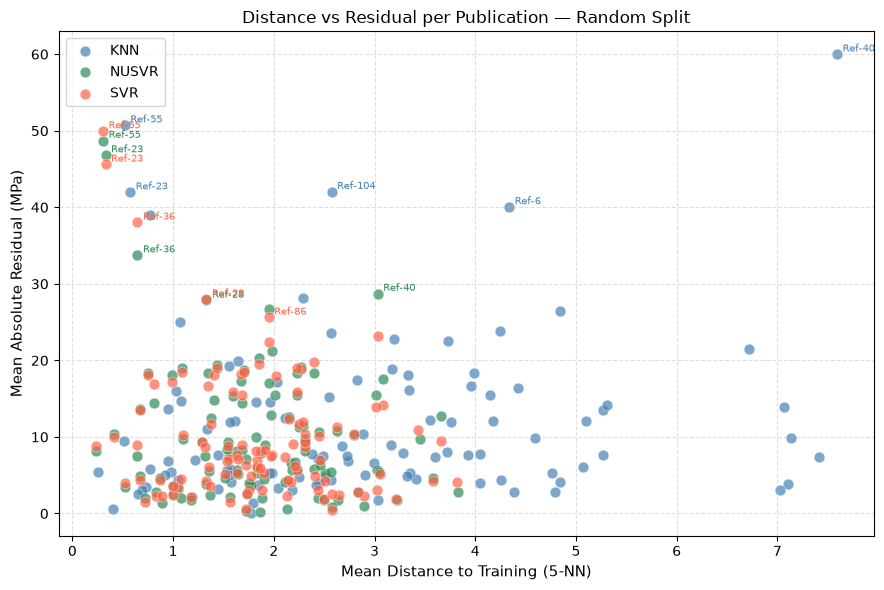

In [26]:
import matplotlib.pyplot as plt

all_cal = pd.concat([
    calibration_knn.assign(model='knn'),
    calibration_svr.assign(model='svr'),
    calibration_nusvr.assign(model='nusvr'),
], ignore_index=True)

colors = {'knn': 'steelblue', 'svr': 'tomato', 'nusvr': 'seagreen'}

fig, ax = plt.subplots(figsize=(9, 6))

for model_name, grp in all_cal.groupby('model'):
    ax.scatter(grp['mean_distance'], grp['mean_residual'],
               label=model_name.upper(), color=colors[model_name],
               alpha=0.7, edgecolors='white', linewidths=0.4, s=60)

for model_name, grp in all_cal.groupby('model'):
    for _, row in grp.nlargest(5, 'mean_residual').iterrows():
        ax.annotate(row['publication'].replace('-Research', '').replace('-data', ''),
                    xy=(row['mean_distance'], row['mean_residual']),
                    fontsize=7, color=colors[model_name],
                    xytext=(4, 2), textcoords='offset points')

ax.set_xlabel('Mean Distance to Training (5-NN)', fontsize=11)
ax.set_ylabel('Mean Absolute Residual (MPa)', fontsize=11)
ax.set_title('Distance vs Residual per Publication — Random Split', fontsize=12)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

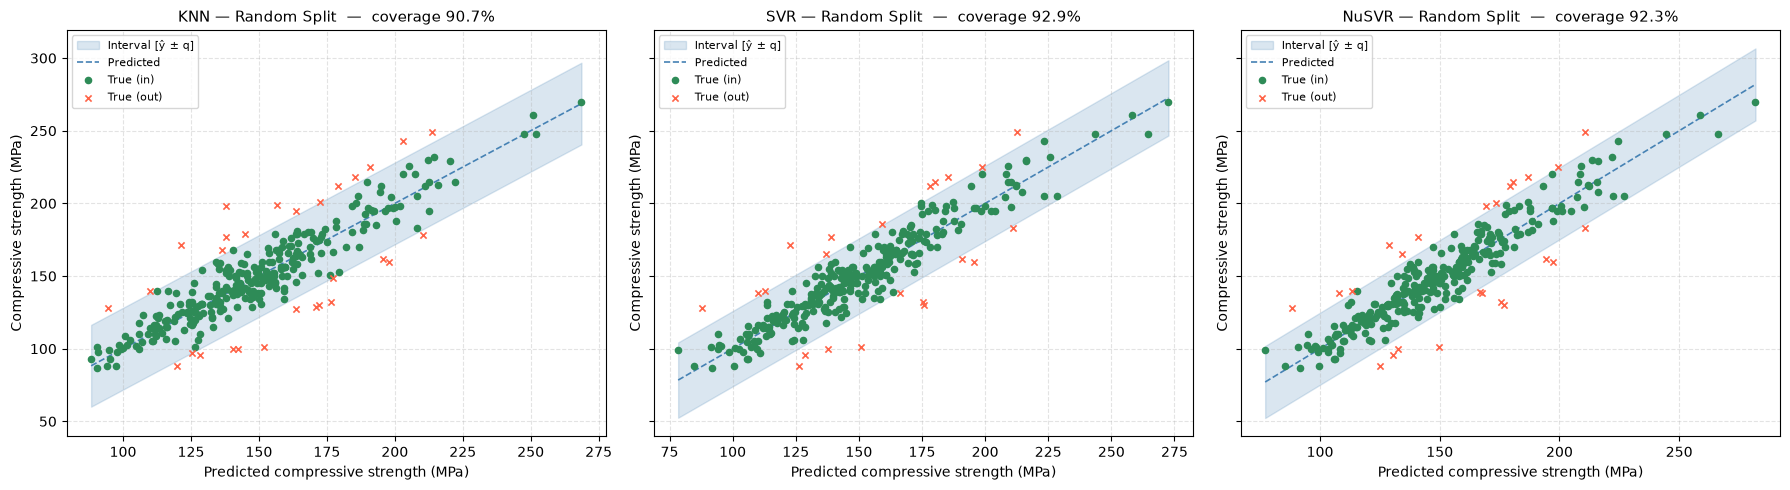

In [ ]:


fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, ivs, label in zip(
    axes,
    [intervals_knn, intervals_svr, intervals_nusvr],
    ["KNN", "SVR", "NuSVR"],
):
    plot_interval_band(ivs, f"{label} — Random Split", ax=ax)
plt.tight_layout()
plt.show()